# 02 — Define the target, engineer features, split, and explore

This notebook performs the Chapter 2 preparation stage. It first constructs the
label and predictors, then reserves chronological validation and test periods.
All exploratory analysis below uses **training data only**.

In [11]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "pyproject.toml").exists():
    raise FileNotFoundError("Run this notebook from the project root or notebooks folder.")

# This fallback makes the src-layout package importable even before an editable install.
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from market_volatility.data import (
    chronological_split,
    load_yahoo_data,
    save_modeling_data,
)

from market_volatility.features import (
    FEATURE_COLUMNS,
    FORWARD_HORIZON,
    TARGET_COLUMN,
    make_modeling_dataset,
)

from market_volatility.plotting import save_figure

SYMBOL = "SPY"
VALIDATION_START = "2016-01-01"
TEST_START = "2021-01-01"

## 1. Define 20-day forward realized volatility

Let adjusted-close log return be

\[
r_t = \log(P_t/P_{t-1}).
\]

The supervised label dated (t) is

\[
y_t = \sqrt{\frac{252}{20}\sum_{i=1}^{20}r_{t+i}^2}.
\]

It is the annualized root-mean-square return realized over the **next** 20
trading days. A value of `0.20` means about 20% annualized volatility. The code
uses `rolling(20).mean().shift(-20)`: the shift aligns returns `t+1` through
`t+20` with predictors known at `t`.

## 2. Financially sensible features

All inputs dated `t` use only observations available by that day's close:

- **Returns:** recent direction and momentum over 1, 5, 20, and 60 sessions.
- **Volatility:** trailing 5/20/60-day realized volatility, downside volatility,
  and Parkinson volatility from the high-low range.
- **Trading session:** scale-free intraday range, overnight return, and intraday
  return.
- **Volume:** log change, ratio to the trailing 20-day mean, and trailing
  60-day z-score.
- **Trend:** adjusted price relative to 20- and 60-day moving averages.

Raw prices and raw dollar ranges are omitted: they trend with the price level and
are not comparable across decades.

In [3]:
raw_prices = load_yahoo_data(SYMBOL)
modeling_data = make_modeling_dataset(raw_prices)

print(f"Raw rows: {len(raw_prices):,}")
print(f"Complete modeling rows: {len(modeling_data):,}")
print(f"Feature count: {len(FEATURE_COLUMNS)}")
print(f"Target: {TARGET_COLUMN}")

display(modeling_data.head())

Raw rows: 8,458
Complete modeling rows: 8,378
Feature count: 18
Target: target_forward_rv_20d


,log_return_1d,return_5d,return_20d,return_60d,abs_return_1d,rv_5,rv_20,rv_60,downside_rv_20,parkinson_rv_20,intraday_range,overnight_return,intraday_return,volume_log_change_1d,volume_ratio_20,volume_zscore_60,price_to_sma_20,price_to_sma_60,target_forward_rv_20d
Date,,,,,,,,,,,,,,,,,,,
1993-04-27,0.010742,-0.014846,-0.027399,0.003289,0.010742,0.134365,0.118374,0.119568,0.097297,0.083454,0.012182,-0.001441,0.012182,0.918206,1.203654,0.277863,-0.014183,-0.014809,0.100932
1993-04-28,-0.002140,-0.016284,-0.032306,-0.005939,0.002140,0.135129,0.118210,0.118764,0.097593,0.083744,0.004280,-0.001426,-0.000714,-0.601787,0.651918,-0.343967,-0.014699,-0.016819,0.109870
1993-04-29,0.004274,0.000712,-0.027341,-0.003780,0.004274,0.104999,0.119154,0.119007,0.097562,0.084368,0.007849,0.002139,0.002134,-0.010533,0.651666,-0.340446,-0.009120,-0.012546,0.109497
1993-04-30,0.001420,0.006408,-0.022457,-0.012876,0.001420,0.101019,0.118626,0.117076,0.096784,0.083937,0.005662,0.003547,-0.002127,0.040351,0.689333,-0.269894,-0.006592,-0.010931,0.110715
1993-05-03,0.006368,0.020664,0.004949,-0.010684,0.006368,0.095458,0.094899,0.117490,0.061564,0.081858,0.009210,0.001418,0.004949,-0.094745,0.621910,-0.349859,-0.000493,-0.004436,0.113645


## 3. Chronological train/validation/test split

Random splitting would let future market regimes influence training. We use:

- Train: before 2016
- Validation: 2016–2020
- Test: 2021 onward

The final 20 candidate observations before validation and test are discarded.
Their labels would otherwise contain returns from the next partition. This is a
**purged chronological split**.

In [4]:
splits = chronological_split(
    modeling_data,
    validation_start = VALIDATION_START,
    test_start = TEST_START,
    purge_horizon = FORWARD_HORIZON,
)

saved_paths = save_modeling_data(modeling_data, splits)

split_summary = pd.DataFrame(
    {
        "rows": [len(splits.train), len(splits.validation), len(splits.test)],
        "first_date": [
            splits.train.index.min(),
            splits.validation.index.min(),
            splits.test.index.min(),
        ],
        "last_date": [
            splits.train.index.max(),
            splits.validation.index.max(),
            splits.test.index.max(),
        ],
    },
    index=["train", "validation", "test"],
)

display(split_summary)
print("Saved files:")

for name, path in saved_paths.items():
    print(f"  {name}: {path}")

,rows,first_date,last_date
train,5694,1993-04-27,2015-12-02
validation,1239,2016-01-04,2020-12-02
test,1405,2021-01-04,2026-08-07


Saved files:
  modeling_dataset: /Users/tonyli/Desktop/hands-on-ml-experiment/data/processed/modeling_dataset.csv
  train: /Users/tonyli/Desktop/hands-on-ml-experiment/data/processed/train.csv
  validation: /Users/tonyli/Desktop/hands-on-ml-experiment/data/processed/validation.csv
  test: /Users/tonyli/Desktop/hands-on-ml-experiment/data/processed/test.csv


In [ ]:
print(f"Number of observations in training set: {len(splits.train)}")
print(f"Number of observations in validation set: {len(splits.validation)}")
print(f"Number of observations in test set: {len(splits.test)} \n")

# There is a 40 record difference between the complete modeling data and the sum of observations from train, validation, and test sets.
# This is due to purging 20 records at the end of the training set and purging 20 records at the end of the validation set. 
print(f"Number of observations removed due to chronological split: {len(modeling_data) - len(splits.train) - len(splits.validation) - len(splits.test)}")

# There is an 80 record count difference between the modeling data and the raw Yahoo finance data. 
# This is due to the earliest 60 records having Null values of past 60-day volatility measures, and the last 20 records having Null 20-day forward 
# volatility measures. 
print(f"Number of observations removed due to creating features: {len(raw_prices) - len(modeling_data)}")

Number of observations in training set: 5694
Number of observations in validation set: 1239
Number of observations in test set: 1405 

Number of observations removed due to chronological split: 40
Number of observations removed due to creating features: 80


## 4. Exploratory analysis—training period only

From this point through model selection, do not inspect validation/test outcomes
except by the planned metrics. Exploration of the held-out target would leak
knowledge into feature and model choices.

In [ ]:
train = splits.train

# Summary table for each feature that was created on the raw data. 
print("Missing values:", int(train.isna().sum().sum()))
display(train.describe().T)

Missing values: 0


,count,mean,std,min,25%,50%,75%,max
log_return_1d,5694.0,0.000349,0.011942,-0.103637,-0.004802,0.000679,0.005956,0.135577
return_5d,5694.0,0.001737,0.024354,-0.220564,-0.010078,0.003423,0.015098,0.177339
return_20d,5694.0,0.006886,0.045071,-0.348222,-0.015060,0.012500,0.033419,0.212051
return_60d,5694.0,0.020363,0.075909,-0.527698,-0.011820,0.029723,0.066843,0.327381
abs_return_1d,5694.0,0.008049,0.008828,0.000000,0.002401,0.005474,0.010638,0.135577
rv_5,5694.0,0.155082,0.109140,0.009000,0.085816,0.128367,0.191651,1.331729
rv_20,5694.0,0.162383,0.097928,0.048975,0.099145,0.137691,0.195572,0.924247
rv_60,5694.0,0.166660,0.090357,0.064298,0.108921,0.140457,0.200351,0.754295
downside_rv_20,5694.0,0.110453,0.077414,0.009726,0.059254,0.095009,0.138575,0.685534
parkinson_rv_20,5694.0,0.140728,0.080499,0.043878,0.087683,0.118834,0.166473,0.757595


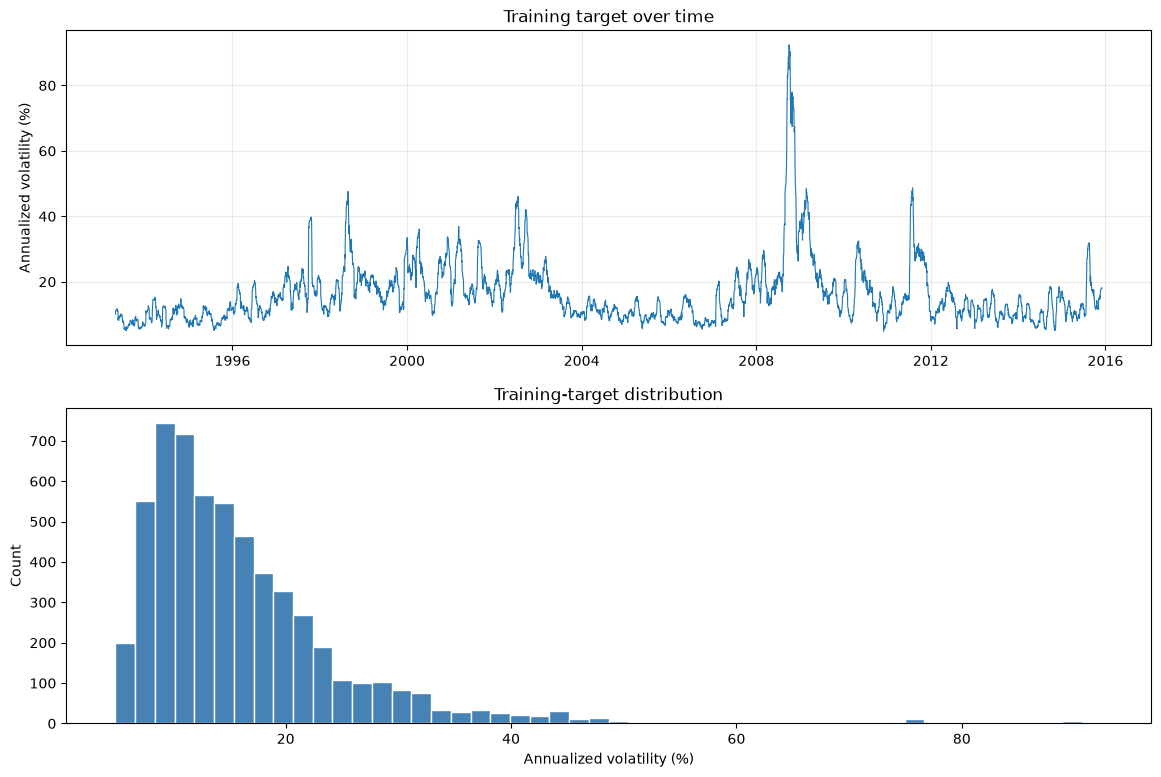

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Create time series graph of target 20-day forward volatility measure. 
axes[0].plot(train.index, 100 * train[TARGET_COLUMN], linewidth = 0.8)
axes[0].set(title = "Training target over time", ylabel = "Annualized volatility (%)")
axes[0].grid(alpha = 0.25)

# Create histogram to examine distribution of target 20-day forward volatility measure. 
axes[1].hist(100 * train[TARGET_COLUMN], bins = 50, color = "steelblue", edgecolor = "white")
axes[1].set(title = "Training-target distribution", xlabel = "Annualized volatility (%)", ylabel = "Count")

save_figure(fig, "02_training_target")

plt.show()

,correlation_with_target
parkinson_rv_20,0.739029
downside_rv_20,0.726104
rv_20,0.716671
rv_5,0.693365
rv_60,0.667504
intraday_range,0.658400
return_60d,-0.511893
price_to_sma_60,-0.510455
abs_return_1d,0.465722
return_20d,-0.417094


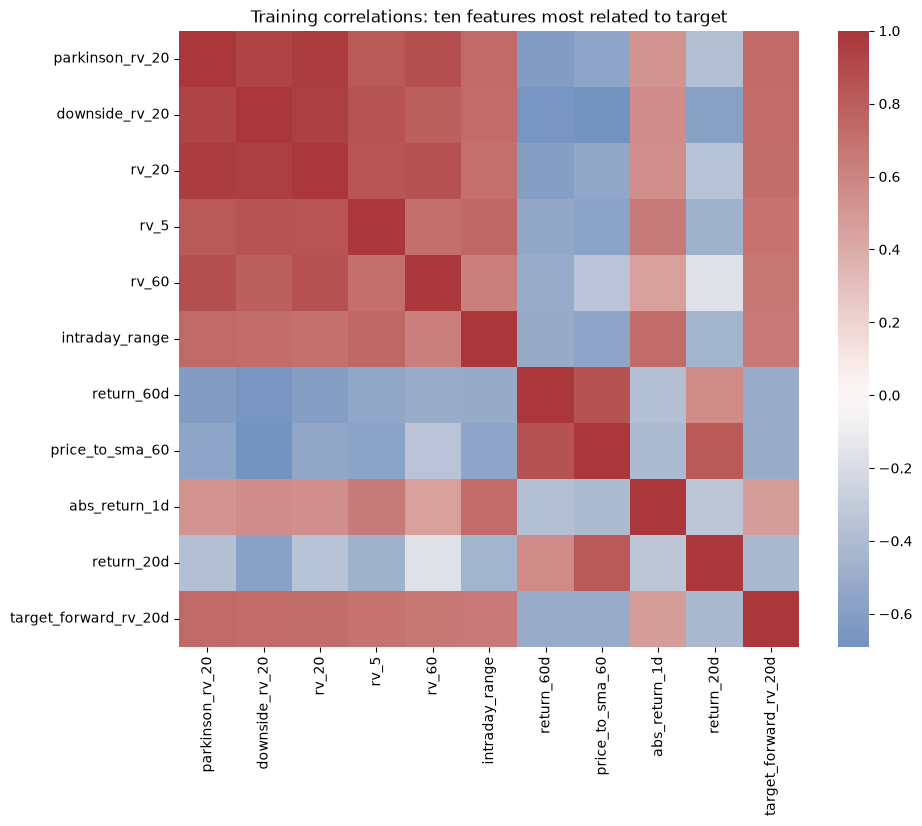

In [ ]:
# Calculate correlation of each feature with target 20-day forward volatility measure.
target_correlations = (
    train.corr(numeric_only = True)[TARGET_COLUMN]
    .drop(TARGET_COLUMN)
    .sort_values(key = abs, ascending = False)
)

display(target_correlations.to_frame("correlation_with_target"))

# Create heat map of top 10 correlated features by absolute value with target 20-day forward volatility. 
top_columns = list(target_correlations.head(10).index) + [TARGET_COLUMN]
fig, ax = plt.subplots(figsize = (10, 8))
sns.heatmap(train[top_columns].corr(), cmap = "vlag", center = 0, ax = ax)
ax.set_title("Training correlations: ten features most related to target")

save_figure(fig, "02_training_correlations")

plt.show()

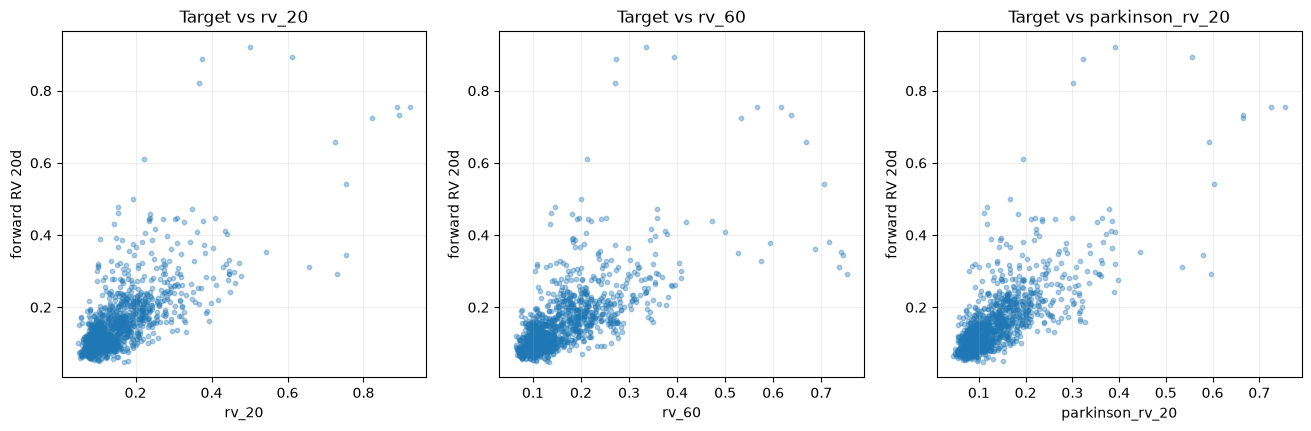

In [ ]:
# Examine data point relationship of 20-day, 60-day, and Parkinson 20-day realized volatility with 20-day forward target volatility.
sample = train.iloc[::5]
fig, axes = plt.subplots(1, 3, figsize = (16, 4.5))

for axis, feature in zip(axes, ["rv_20", "rv_60", "parkinson_rv_20"]):
    axis.scatter(sample[feature], sample[TARGET_COLUMN], s = 10, alpha = 0.35)
    axis.set(xlabel = feature, ylabel = "forward RV 20d", title = f"Target vs {feature}")
    axis.grid(alpha = 0.2)

save_figure(fig, "02_target_feature_relationships")

plt.show()

### What to look for

Volatility should cluster: high-volatility observations tend to follow other
high-volatility observations. The target is right-skewed, and current/trailing
volatility should be among its strongest relationships. Strong correlation does
not prove causation; it only motivates honest out-of-sample testing.